# Run Model Notebook (Clean)

This notebook runs a single-country simulation end-to-end and provides a compact analysis workflow.

## How To Use
1. Update parameters in **Inputs**.
2. Run all cells from top to bottom.
3. Review validation summaries and plots.

## Prerequisites
- Environment with project dependencies installed.
- Data available at `data/hfcs/raw` (or set `RAW_DATA_PATH`).


## Sections
- Setup
- Inputs
- Data Preparation
- Country Configuration
- Run Simulation
- Outputs And Plots
- National Accounts Comparison
- Optional Scenario Comparison


In [16]:
# Setup
%load_ext autoreload
%autoreload 2

import logging
import os
import random
from pathlib import Path
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import Config
from macro_data import DataWrapper
from macro_data.configuration import DataConfiguration, split_country_configs
from macro_data.configuration_utils import default_data_configuration, read_country_conf
from macromodel.configurations import CountryConfiguration, SimulationConfiguration
from macromodel.simulation import Simulation
from macromodel.util.loader import Loader
from src.helpers import align_country_configuration_to_data, unpack_cell
from src.visual_helpers import build_macro_output_df, plot_output

logging.getLogger().setLevel(logging.ERROR)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
# Inputs
seed = 23 # 32
t_max = 50

# Optional overrides (None means use Config/default env values)
seed_override = seed
country_override = None
raw_data_path_override = None
output_dir_override = None
t_max_override = t_max

cfg = Config().from_env()
if country_override is not None:
    cfg.country_iso3 = country_override
if t_max_override is not None:
    cfg.t_max = t_max_override
if seed_override is not None:
    cfg.seed = seed

random.seed(cfg.seed)

raw_data_path = Path(raw_data_path_override) if raw_data_path_override else (cfg.raw_data_path or Path('data/hfcs/raw'))
output_dir = Path(output_dir_override) if output_dir_override else (cfg.output_path or Path('data/output'))
output_dir.mkdir(parents=True, exist_ok=True)

data_pkl_path = output_dir / 'data.pkl'
model_h5_path = output_dir / 'multi_country_simulation.h5'

print({'seed': cfg.seed, 'country': cfg.country_iso3, 't_max': cfg.t_max, 'raw_data_path': str(raw_data_path), 'output_dir': str(output_dir)})


{'seed': 23, 'country': 'FRA', 't_max': 50, 'raw_data_path': '/Users/andone/Documents/python_projects/macro-main/run_model/data/raw_data', 'output_dir': '/Users/andone/Documents/python_projects/macro-main/run_model/data/output_data'}


In [18]:
# Data Preparation
assert raw_data_path.exists(), f'Raw data path not found: {raw_data_path}'

# Load data configuration
with open(f"{cfg.config_dir}/data_config_FRA.yaml", "r") as f:
    data_config = yaml.safe_load(f)
data_config["country_configs"] = split_country_configs(data_config["country_configs"])
data_config = DataConfiguration(**data_config)

#  Create country data
creator = DataWrapper.from_config(
    configuration=data_config,
    raw_data_path=raw_data_path,
    single_hfcs_survey=True,
)
creator.save(str(data_pkl_path))
data = DataWrapper.init_from_pickle(str(data_pkl_path))

synthetic_country = creator.synthetic_countries[cfg.country_iso3]
na = synthetic_country.exogenous_data.national_accounts

In [19]:
# Load country configuration
with open(f"{cfg.config_dir}/country_config_FRA.yaml", "r") as f:
    country_config_dict = yaml.safe_load(f)
country_cfg = CountryConfiguration(**country_config_dict[cfg.country_iso3])
country_cfg = align_country_configuration_to_data(country_cfg, n_industries=data.n_industries)
country_configurations = {cfg.country_iso3: country_cfg}

# Modify loaded country config
country_cfg = country_configurations[cfg.country_iso3]
country_cfg.firms.functions.productivity_growth.name = 'SimpleTFPGrowth'  #'NoOpTFPGrowth'
country_cfg.labour_market.functions.clearing.name = 'PolednaLabourMarketClearer'
country_cfg.central_bank.functions.policy_rate.name = 'PolednaPolicyRate'
country_cfg.government_entities.functions.consumption.name = 'AutoregressiveGovernmentConsumptionSetter'
# country_cfg.government_entities.functions.consumption.name = 'ConstantGrowthGovernmentConsumptionSetter'

# "AutoregressiveGovernmentConsumptionSetter",
# "ConstantGrowthGovernmentConsumptionSetter",
# "ExogenousGovernmentConsumptionSetter"

# # Labour market and policy
# country_cfg.labour_market.functions.clearing.parameters['hiring_speed'] = 0.9
# country_cfg.labour_market.functions.clearing.parameters['firing_speed'] = 0.9
# country_cfg.labour_market.functions.clearing.parameters['random_firing_probability'] = 0.01
# country_cfg.labour_market.functions.clearing.parameters['individuals_quitting'] = True
# country_cfg.labour_market.functions.clearing.parameters['individuals_quitting_temperature'] = 0.3
# country_cfg.labour_market.functions.clearing.parameters['compare_with_normalised_inputs'] = True
# country_cfg.labour_market.functions.clearing.parameters['firing_cost_fraction'] = 0.05
# country_cfg.labour_market.functions.clearing.parameters['hiring_cost_fraction'] = 0.02

print('Configuration summary')
print({'productivity_growth': country_cfg.firms.functions.productivity_growth.name,
       'labour_market_clearer': country_cfg.labour_market.functions.clearing.name,
       'policy_rate_rule': country_cfg.central_bank.functions.policy_rate.name})


Configuration summary
{'productivity_growth': 'SimpleTFPGrowth', 'labour_market_clearer': 'PolednaLabourMarketClearer', 'policy_rate_rule': 'PolednaPolicyRate'}


In [20]:
# Run single Simulation
configuration = SimulationConfiguration(
    country_configurations=country_configurations,
    t_max=cfg.t_max,
    seed=cfg.seed,
)

model = Simulation.from_datawrapper(
    datawrapper=data,
    simulation_configuration=configuration,
)

import warnings
warnings.simplefilter("always", RuntimeWarning)

model.run()
model.save(save_dir=output_dir, file_name=model_h5_path.name)

print(f'Simulation complete. Output saved to: {model_h5_path}')


# Outputs And Plots
plot_columns = [
    'total consumption to gdp', 'investment to gdp', 'net exports to gdp',
    'debt to gdp', 'fiscal revenue to gdp', 'fiscal expenditure to gdp', 'deficit to gdp',
    'household consumption to gdp', 'government consumption to gdp', 'gdp',
    'gdp growth', 'unemployment rate', 'central bank policy rate', 
    'wages', 'profits', 'cpi', 'ppi',
    'taxes paid on production', 'taxes on products',  'government consumption',
    # 'Imports', 'Exports',
    # 'Consumption Expansion Loan Debt', 'Mortgage Debt',
]

# df_base = build_macro_output_df(cfg, model, country_code=cfg.country_iso3)
df_base = build_macro_output_df(model, country_code=cfg.country_iso3)
n_rows = 6
n_cols = 3

plot_output(
    df=df_base[plot_columns],
    no_rows=n_rows,
    no_cols=n_cols,
    country_code=cfg.country_iso3,
    line_color="#1f77b4",
    base_height=200,
    base_width=400,
)

# df_base.to_csv(cfg.output_path / "macro_output.csv")

Simulation complete. Output saved to: /Users/andone/Documents/python_projects/macro-main/run_model/data/output_data/multi_country_simulation.h5


In [21]:
# Monte Carlo simulations
from src.monte_carlo import run_seeded_monte_carlo

# seeds = [23, 72, 85, 19, 57, 27, 54, 32, 37, 98]
seeds = [i + 1 for i in range(0,10)]
mc = run_seeded_monte_carlo(datawrapper=data,
                            country_configurations=country_configurations,
                            country_code=cfg.country_iso3,
                            seeds=seeds,
                            t_max=cfg.t_max,
                            )

from src.visual_helpers import plot_mc

mc_columns = [
    'total consumption to gdp', 'investment to gdp', 'net exports to gdp',
    'debt to gdp', 'fiscal revenue to gdp', 'fiscal expenditure to gdp', 'deficit to gdp',
    'household consumption to gdp', 'government consumption to gdp', 'gdp',
    'gdp growth', 'unemployment rate', 'central bank policy rate', 
    'wages', 'profits', 'cpi', 'ppi',
    'taxes paid on production', 'taxes on products', 'government consumption',
    # 'Imports', 'Exports',
    # 'Consumption Expansion Loan Debt', 'Mortgage Debt',
]

plot_mc(
    mc=mc,
    cols=mc_columns,
    no_rows=7,
    no_cols=3,
    country_code=cfg.country_iso3,
    base_height=200,
    base_width=400,
    line_opacity=0.5,
    line_width=2
)

In [6]:
#  Sensitivity analysis
from src.sensitivity import run_parameter_sensitivity

param_values = np.linspace(0.01, 0.2, 5).tolist()

res = run_parameter_sensitivity(
    datawrapper=data,
    country_configurations=country_configurations,
    country_code=cfg.country_iso3,
    parameter_path="firms.functions.wage_setter.parameters['labour_market_tightness_markup_scale']",
    parameter_values=param_values,
    seeds=[11,12,13],
    t_max=50,
    n_jobs=-1,
    batch_size=4,
)


In [7]:
from src.visual_helpers import plot_sensitivity_summary, plot_sensitivity

sens_columns = [
    'total consumption to gdp', 'investment to gdp', 'net exports to gdp',
    'debt to gdp', 'fiscal revenue to gdp', 'fiscal expenditure to gdp', 'deficit to gdp',
    'household consumption to gdp', 'government consumption to gdp', 'gdp',
    'gdp growth', 'unemployment rate', 'central bank policy rate', 
    'wages', 'profits', 'cpi', 'ppi',
    'taxes paid on production', 'taxes on products',  'government consumption',
    # 'Imports', 'Exports',
    # 'Consumption Expansion Loan Debt', 'Mortgage Debt',
]


plot_sensitivity(
    sensitivity=res,
    cols=sens_columns,
    country_code=cfg.country_iso3,
    no_cols=4,
    no_rows=6,
    base_height=200,
    base_width=300,
)


# plot_sensitivity_summary(
#     sensitivity=res,
#     cols=sens_columns,
#     country_code=cfg.country_iso3,
#     band=(0.25, 0.75),
# )


Simulation complete. Output saved to: /Users/andone/Documents/python_projects/macro-main/run_model/data/output_data/multi_country_simulation.h5


,gdp_output,gdp_expenditure,gdp_income,total_output,household_fce,government_fce,gfcf,exports,imports,cpi,ppi,estimated_cpi_inflation,estimated_ppi_inflation,unemployment_rate,vacancy_rate,government_revenue,government_deficit,government_debt,policy_rate,firm_insolvency_rate
time,,,,,,,,,,,,,,,,,,,,
24,5.186466e+11,5.186466e+11,5.095115e+11,8.948580e+11,3.319334e+11,2.032490e+09,1.017508e+11,1.233564e+11,1.426364e+11,1.111410,1.111000,0.009183,0.001543,0.324306,0.137732,1.897239e+11,2.104817e+10,4.566775e+12,0.000000,0.000000
25,5.327151e+11,5.327151e+11,5.235800e+11,9.249097e+11,3.301124e+11,1.373046e+09,1.040114e+11,1.258343e+11,1.448296e+11,1.133116,1.142455,-0.004886,0.010140,0.321875,0.137761,1.951906e+11,1.999194e+10,4.586767e+12,0.000000,0.000000
26,5.352701e+11,5.352701e+11,5.259566e+11,9.285907e+11,3.443043e+11,9.021234e+08,1.060030e+11,1.245522e+11,1.465485e+11,1.123327,1.139667,0.021841,0.015884,0.317361,0.136163,1.954582e+11,2.517932e+10,4.611947e+12,0.001552,0.000000
27,5.218177e+11,5.218177e+11,5.125042e+11,9.016611e+11,3.370345e+11,5.343990e+08,1.025745e+11,1.198215e+11,1.418434e+11,1.104012,1.117540,-0.006091,-0.005434,0.315278,0.147701,1.944756e+11,2.918138e+10,4.641128e+12,0.002401,0.000000
28,5.095243e+11,5.095243e+11,5.002107e+11,8.784929e+11,3.316515e+11,2.923729e+08,9.739426e+10,1.198250e+11,1.373081e+11,1.076362,1.083365,-0.007288,-0.016572,0.312847,0.148956,1.921963e+11,1.293297e+10,4.654061e+12,0.000000,0.055556
29,5.036835e+11,5.036835e+11,4.943700e+11,8.680284e+11,3.272707e+11,1.644780e+08,9.512631e+10,1.166784e+11,1.359526e+11,1.068805,1.069940,0.006179,-0.002744,0.314236,0.153116,1.922575e+11,1.082044e+10,4.664881e+12,0.000000,0.000000
30,4.876815e+11,4.876815e+11,4.783680e+11,8.398010e+11,3.245951e+11,9.365647e+07,9.350758e+10,1.173476e+11,1.333602e+11,1.038690,1.039467,0.001982,0.013458,0.315625,0.155760,1.916313e+11,6.065776e+09,4.670947e+12,0.000000,0.000000
31,4.857808e+11,4.857808e+11,4.764672e+11,8.395855e+11,3.115619e+11,5.198517e+07,9.231397e+10,1.178629e+11,1.327094e+11,1.037557,1.040858,-0.027379,0.003430,0.317361,0.157884,1.891929e+11,9.060933e+09,4.680008e+12,0.000000,0.000000
32,4.776702e+11,4.776702e+11,4.683567e+11,8.309631e+11,3.138790e+11,2.576648e+07,8.954857e+10,1.118155e+11,1.323989e+11,1.022179,1.027008,-0.017667,-0.002564,0.319792,0.157346,1.923926e+11,2.732482e+09,4.682741e+12,0.000000,0.000000


,label,dataset_path,condition,threshold,first_trigger_time,triggered
4,gdp_output_below_1tn,/FRA/economy/gdp_output,below,1.000000e+12,24.0,True
0,exports_reach_zero,/FRA/economy/total_exports,equals,0.000000e+00,NaN,False
1,gfcf_below_10bn,/FRA/economy/total_gross_fixed_capital_formation,below,1.000000e+10,NaN,False
2,firm_deposits_below_minus_1tn,/FRA/firms/deposits,any_below,-1.000000e+12,NaN,False
3,all_firm_deposits_negative,/FRA/firms/deposits,all_below,0.000000e+00,NaN,False
5,unemployment_flat_window,/FRA/economy/unemployment_rate,constant,0.000000e+00,NaN,False


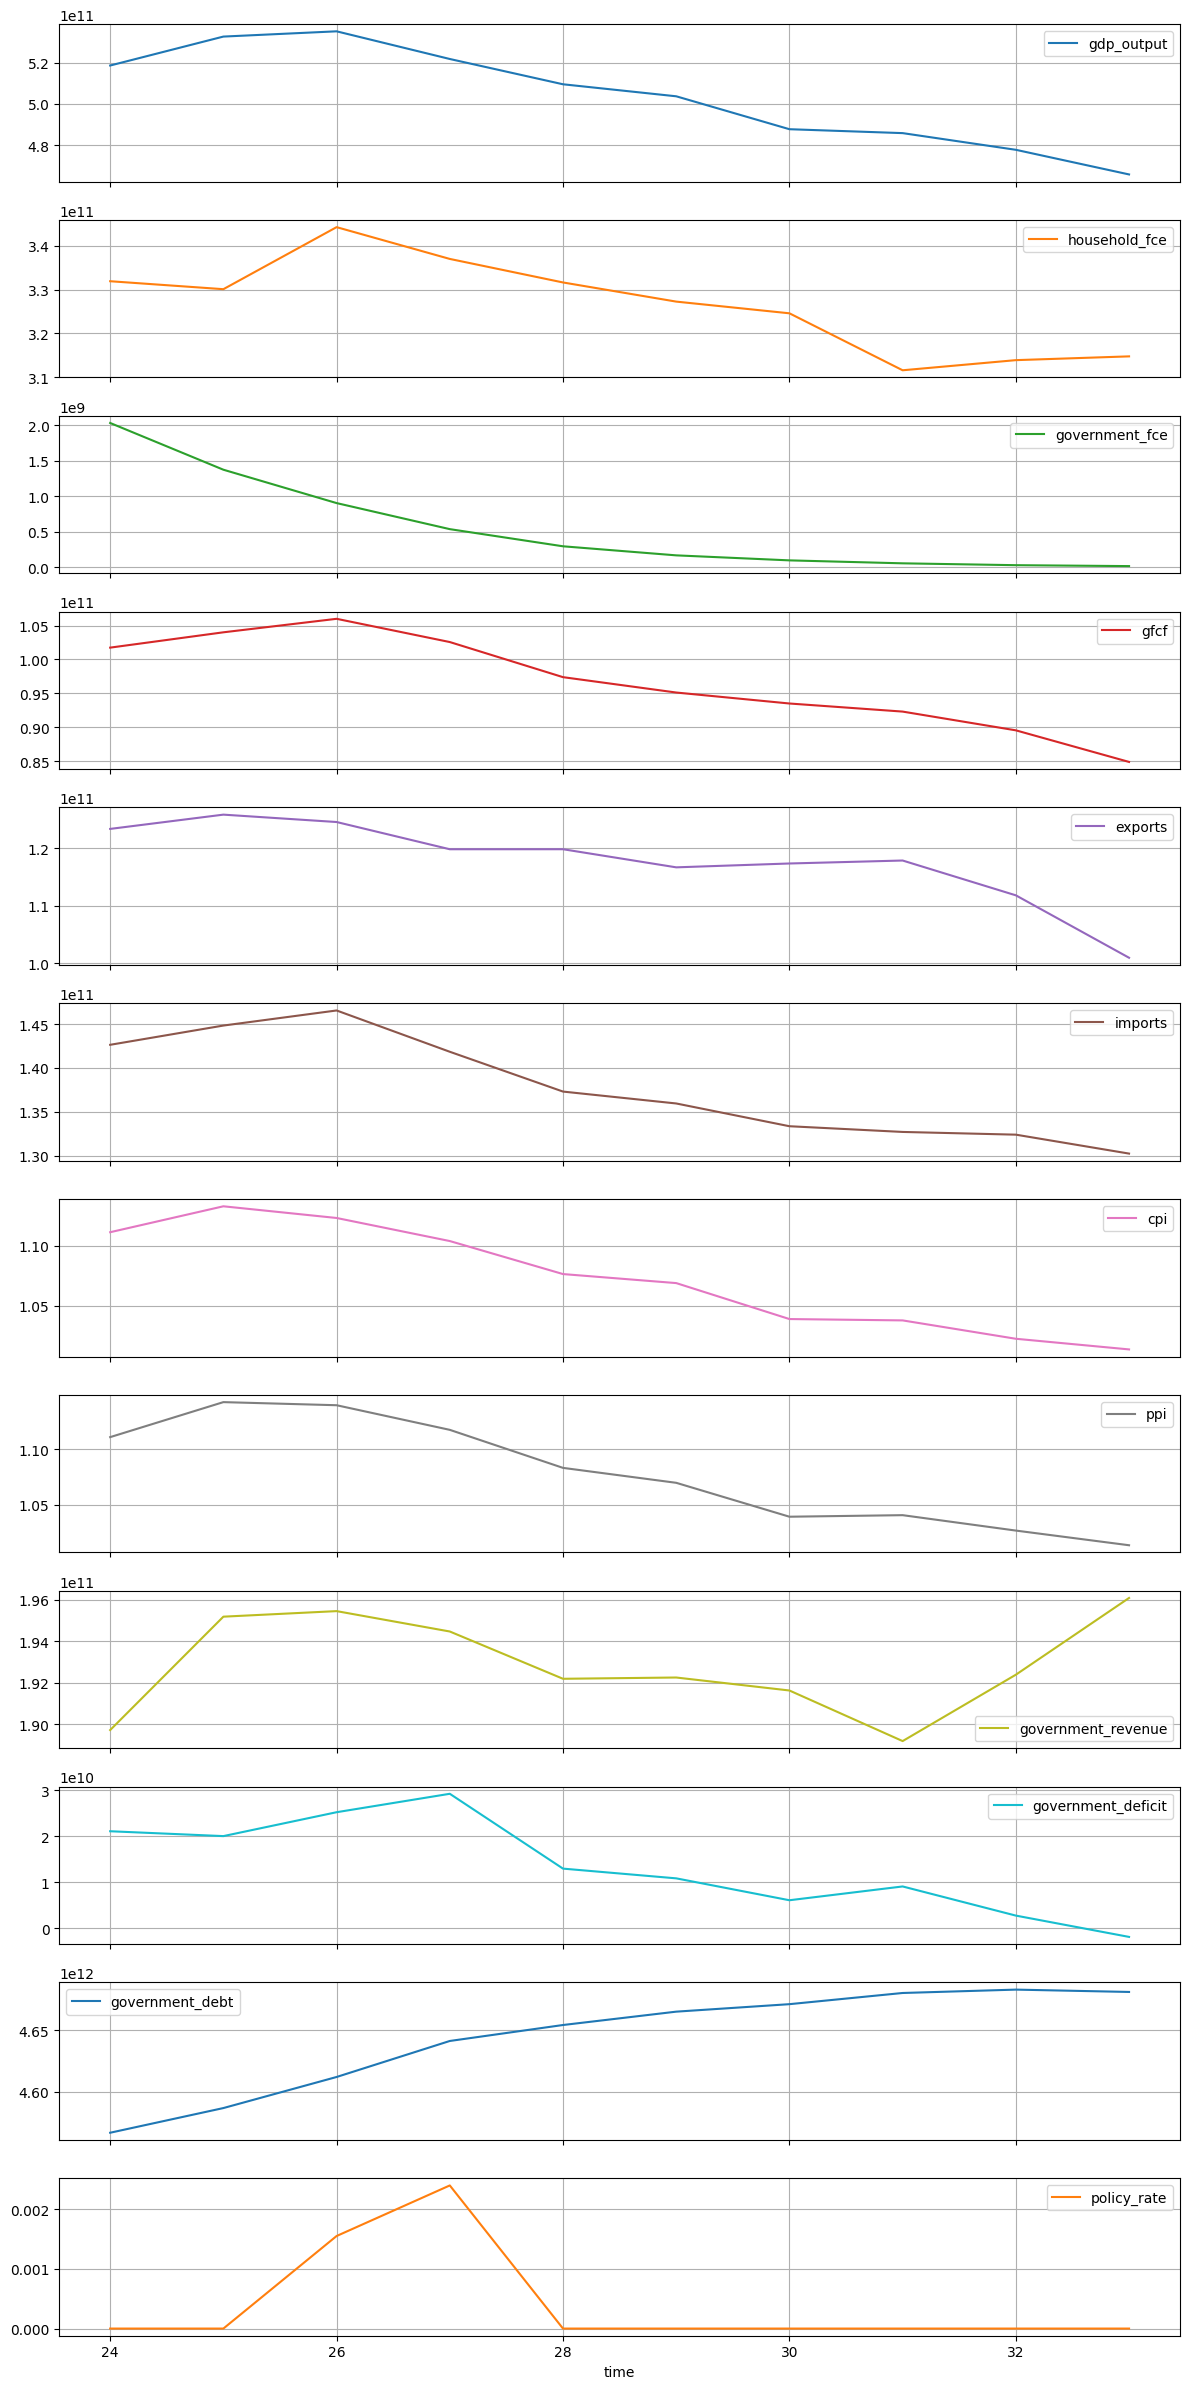

In [11]:
# DEBUG

from src.collapse_debug import (
    summarize_collapse_diagnostics,
    compare_unemployment_to_exogenous,
    first_entity_drop_below_threshold,
)

h5_path = Path("data/output_data/multi_country_simulation.h5")

diagnostics = summarize_collapse_diagnostics(
    h5_path,
    country_code="FRA",
    start=24,
    end=33,
)

core = diagnostics["core"]
firms = diagnostics["firms"]
credit = diagnostics["credit"]
thresholds = diagnostics["thresholds"]

labor_cmp = compare_unemployment_to_exogenous(
    h5_path,
    country_code="FRA",
    start=24,
    end=34,
)

first_shutdown = first_entity_drop_below_threshold(
    h5_path,
    "/FRA/firms/desired_labour_inputs",
    threshold=1e-6,
    start=24,
    end=34,
)

display(core)
display(thresholds.sort_values("first_trigger_time", na_position="last"))

import matplotlib.pyplot as plt

core_cols = [
    "gdp_output",
    "household_fce",
    "government_fce",
    "gfcf",
    "exports",
    "imports",
    "cpi",
    "ppi",
    "government_revenue",
    "government_deficit",
    "government_debt",
    "policy_rate",
]

ax = core[core_cols].plot(subplots=True, figsize=(12, 24), legend=True, grid=True)
plt.tight_layout()



,economy_unemployment_rate,economy_vacancy_rate,exogenous_unemployment_rate,exogenous_vacancy_rate
time,,,,
24,0.324306,0.137732,0.08010,NaN
25,0.321875,0.137761,0.08010,NaN
26,0.317361,0.136163,0.08010,NaN
27,0.315278,0.147701,0.08010,NaN
28,0.312847,0.148956,0.08063,NaN
29,0.314236,0.153116,NaN,NaN
30,0.315625,0.155760,NaN,NaN
31,0.317361,0.157884,NaN,NaN
32,0.319792,0.157346,NaN,NaN


,entity,first_time_below_threshold,threshold
0,col_0,None,0.000001
1,col_1,None,0.000001
2,col_2,None,0.000001
3,col_3,None,0.000001
4,col_4,None,0.000001
5,col_5,None,0.000001
6,col_6,None,0.000001
7,col_7,None,0.000001
8,col_8,None,0.000001
9,col_9,None,0.000001


[0, 1, 2, 3, 4]

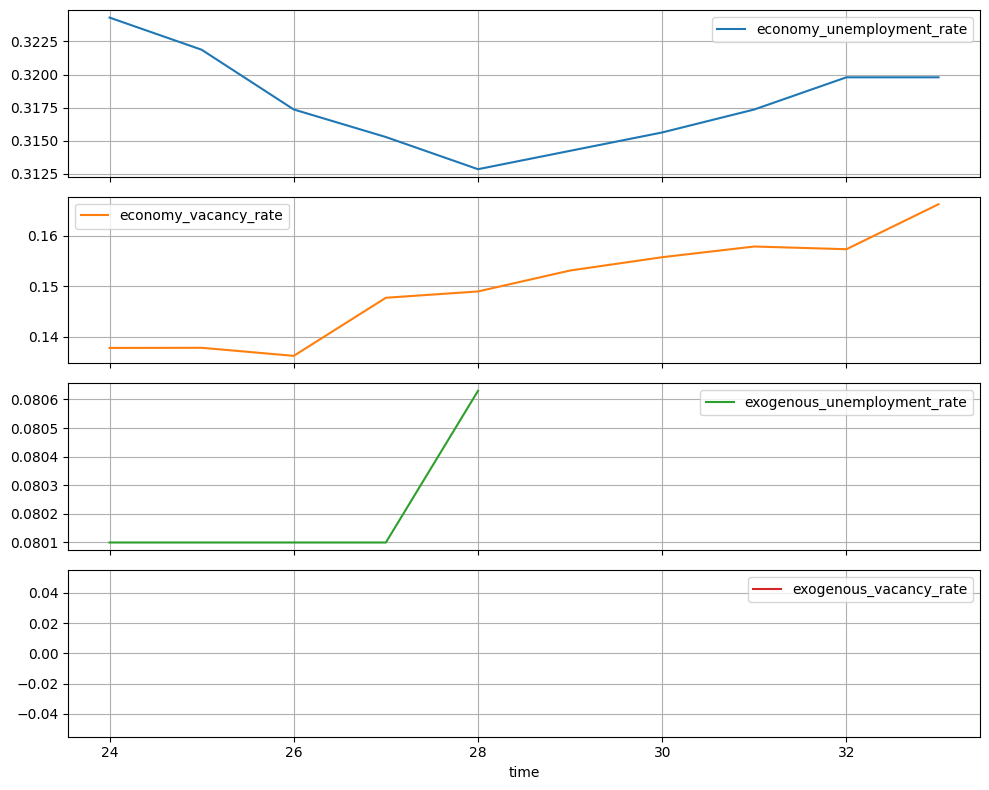

In [12]:
display(labor_cmp)
labor_cmp.plot(subplots=True, figsize=(10, 8), grid=True)
plt.tight_layout()

display(first_shutdown.head(10))
# first_shutdown
shutdown_firms = [int(x.split("_")[1]) for x in first_shutdown["entity"].dropna().head(5)]
shutdown_firms

,profits,deposits,debt,debt_installments,target_short_term_credit,target_long_term_credit,demand,estimated_demand,desired_labour_inputs,target_production,limiting_intermediate_inputs,limiting_capital_inputs,production
time,,,,,,,,,,,,,
24,2.224301e+09,-1.983798e+10,0.0,0.0,2.263341e+11,2.729008e+11,6.738885e+11,6.791284e+11,6.998704e+11,7.495890e+11,5.982884e+11,7.031487e+11,7.010850e+11
25,6.090920e+09,-6.162153e+10,0.0,0.0,2.431858e+11,3.265442e+11,6.605724e+11,6.738885e+11,6.993725e+11,7.439970e+11,5.970739e+11,7.031007e+11,7.007009e+11
26,1.720994e+09,-9.754086e+10,0.0,0.0,3.118030e+11,4.000100e+11,6.758052e+11,6.605724e+11,6.973703e+11,7.306425e+11,5.957454e+11,7.030500e+11,7.064297e+11
27,1.845137e+09,-1.288976e+11,0.0,0.0,3.479484e+11,4.746849e+11,6.717852e+11,6.758052e+11,6.969757e+11,7.464481e+11,5.866860e+11,7.025918e+11,6.979336e+11
28,3.696884e+09,4.500256e+10,0.0,0.0,3.848191e+11,5.355354e+11,6.788609e+11,6.717852e+11,6.977909e+11,7.415786e+11,5.857281e+11,7.025387e+11,6.991750e+11
29,2.149830e+09,1.958390e+10,0.0,0.0,2.080443e+11,2.054702e+11,6.802512e+11,6.788609e+11,6.993390e+11,7.487784e+11,5.843440e+11,7.024875e+11,7.005060e+11
30,-7.355568e+09,2.524941e+08,0.0,0.0,2.524214e+11,2.702254e+11,7.013027e+11,6.802512e+11,6.994007e+11,7.503018e+11,5.831769e+11,7.024411e+11,7.005736e+11
31,-5.393998e+09,-2.764778e+10,0.0,0.0,2.547765e+11,2.832252e+11,6.862282e+11,7.013027e+11,6.996153e+11,7.713600e+11,5.820040e+11,7.023947e+11,7.007829e+11
32,-1.711705e+10,-6.446322e+10,0.0,0.0,3.083071e+11,3.838184e+11,6.951341e+11,6.862282e+11,6.970520e+11,7.563064e+11,5.808364e+11,7.023485e+11,7.030845e+11


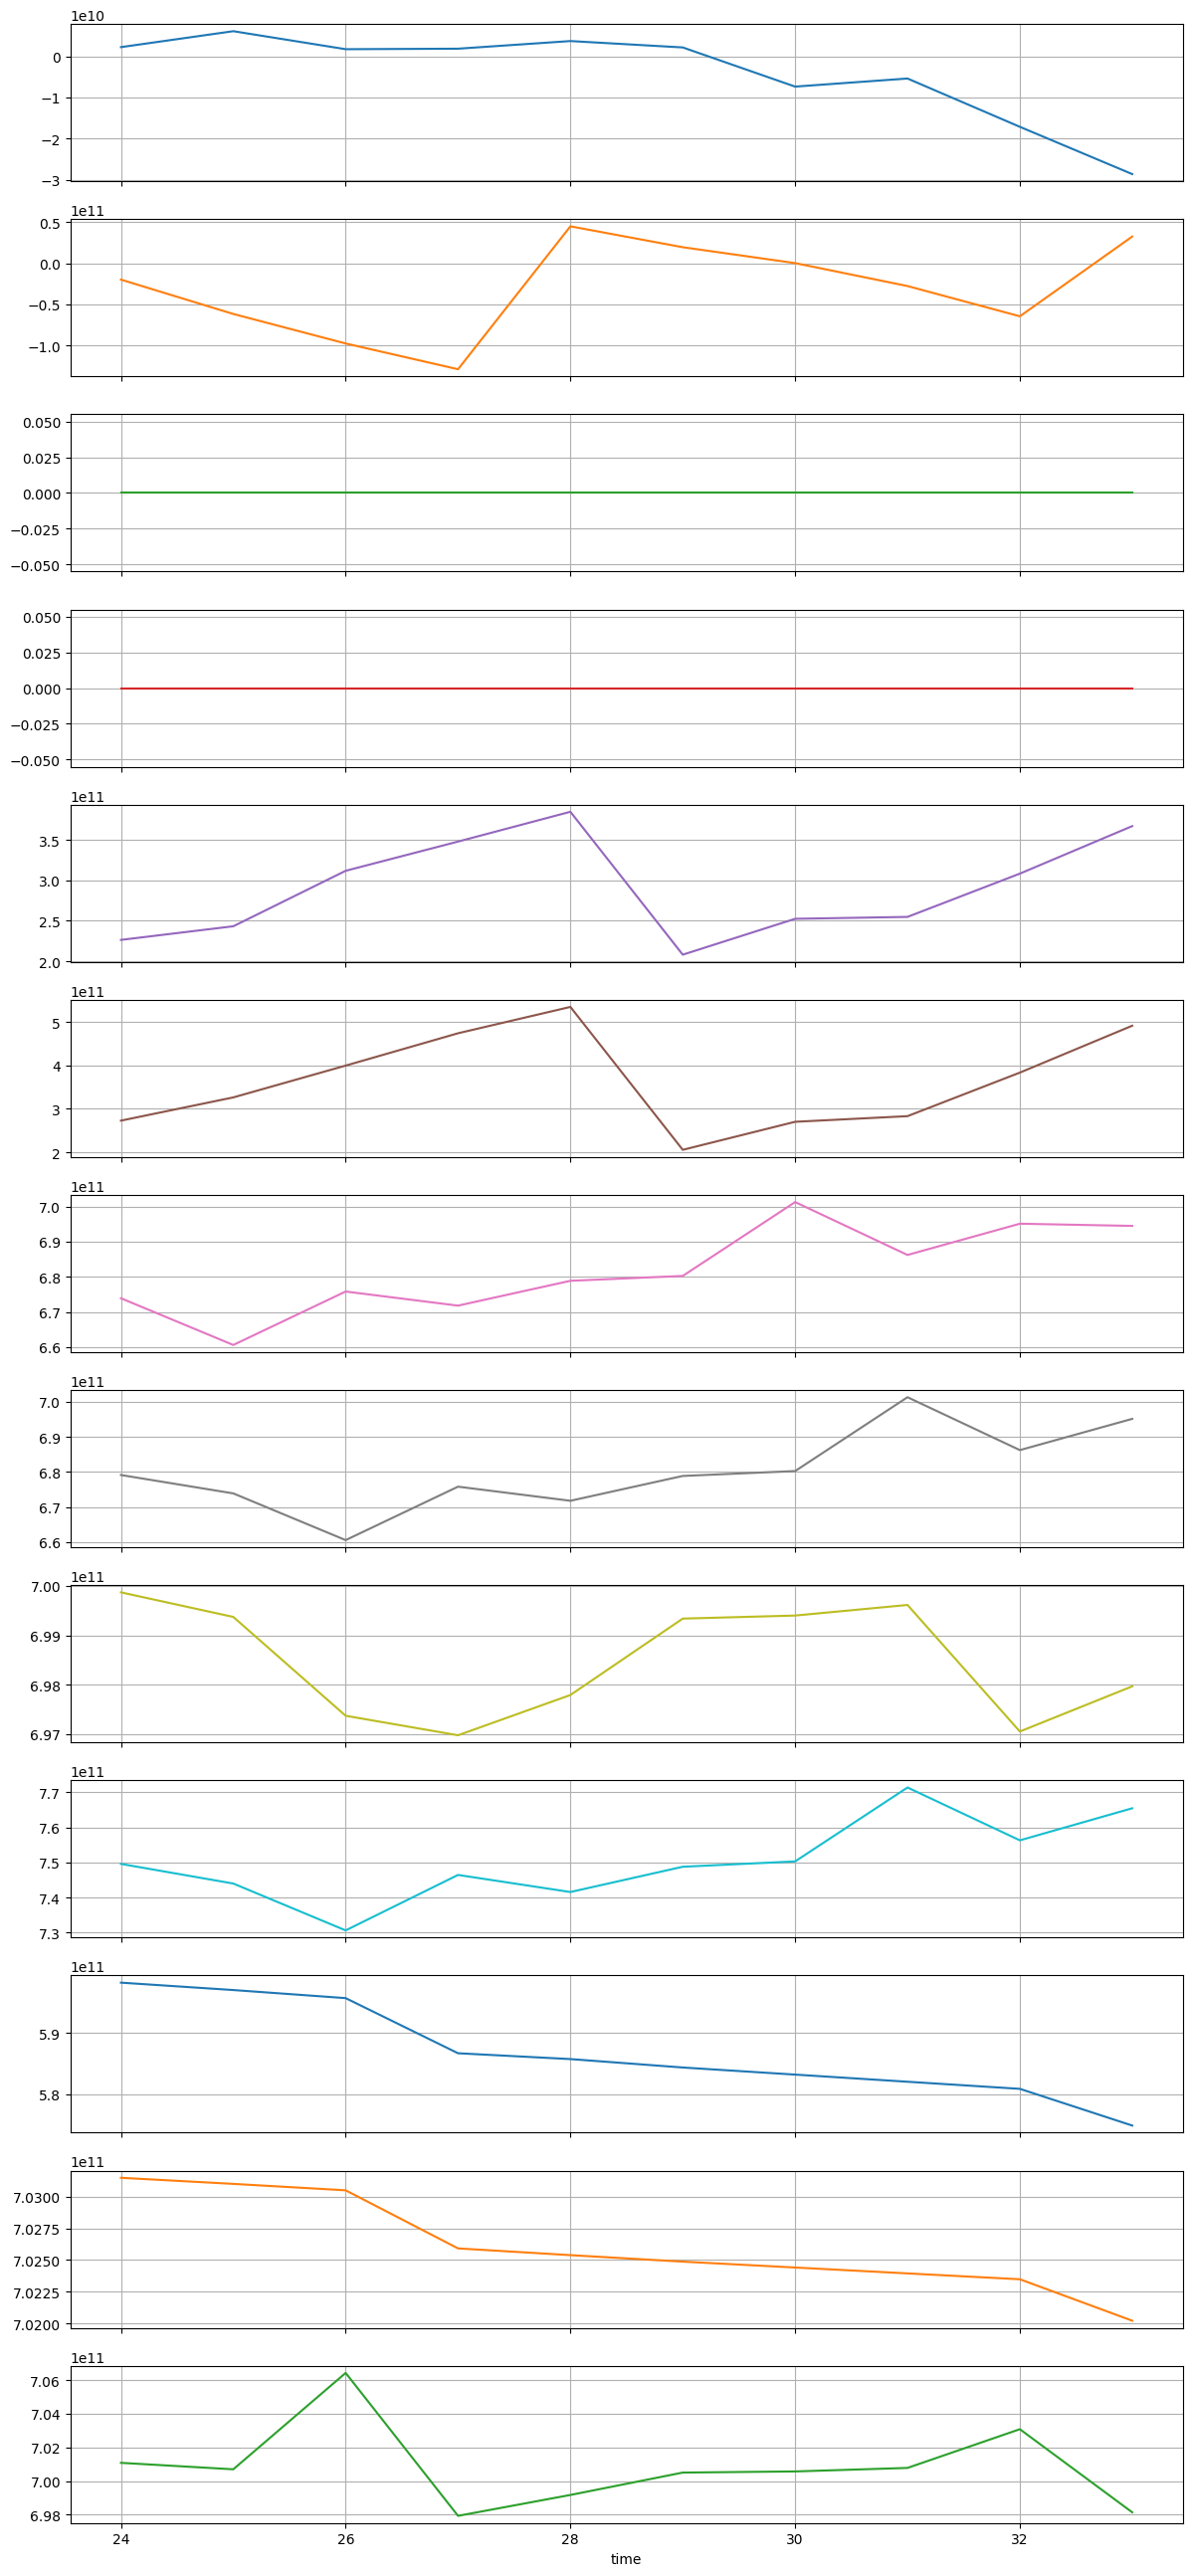

In [13]:
firm_time = firms.groupby(level="time").agg({
    "profits": "sum",
    "deposits": "sum",
    "debt": "sum",
    "debt_installments": "sum",
    "target_short_term_credit": "sum",
    "target_long_term_credit": "sum",
    "demand": "sum",
    "estimated_demand": "sum",
    "desired_labour_inputs": "sum",
    "target_production": "sum",
    "limiting_intermediate_inputs": "sum",
    "limiting_capital_inputs": "sum",
    "production": "sum",
}).loc[24:33]

display(firm_time)
firm_time.plot(subplots=True, figsize=(12, 26), legend=False, grid=True)
plt.tight_layout()


,new_short_term_loans,new_long_term_loans,outstanding_short_term_loans,outstanding_long_term_loans,bank_profits,bank_equity,bank_total_outstanding_loans
time,,,,,,,
24,0.0,0.0,0.0,0.0,1.184658e+10,8.074671e+11,4.110468e+11
25,0.0,0.0,0.0,0.0,1.184655e+10,8.148124e+11,4.067651e+11
26,0.0,0.0,0.0,0.0,1.224563e+10,8.224052e+11,4.024834e+11
27,0.0,0.0,0.0,0.0,1.247007e+10,8.301371e+11,3.982016e+11
28,0.0,0.0,0.0,0.0,1.202637e+10,8.375939e+11,3.939199e+11
29,0.0,0.0,0.0,0.0,1.188943e+10,8.449659e+11,3.896382e+11
30,0.0,0.0,0.0,0.0,1.186590e+10,8.523232e+11,3.853564e+11
31,0.0,0.0,0.0,0.0,1.185468e+10,8.596736e+11,3.810747e+11
32,0.0,0.0,0.0,0.0,1.184997e+10,8.670210e+11,3.767929e+11


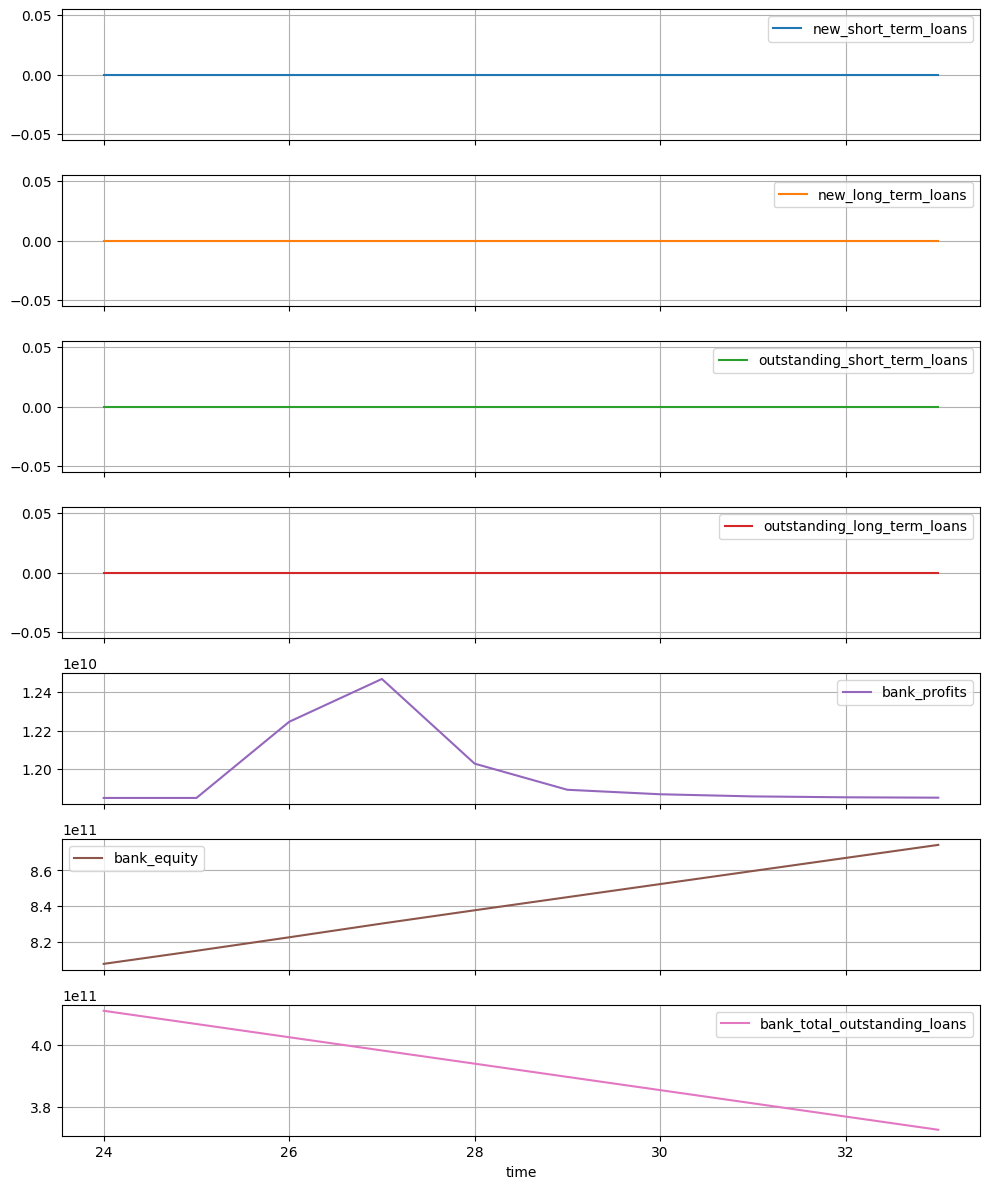

In [14]:
display(credit)
credit.plot(subplots=True, figsize=(10, 12), grid=True)
plt.tight_layout()


### Benchmark Comparison


In [15]:
run_benchmark = True
force_rerun_benchmark = False

if run_benchmark:
    output_dir = cfg.output_path or Path("data/output")
    output_dir.mkdir(parents=True, exist_ok=True)

    data_pkl_path = output_dir / "data_benchmark.pkl"
    df_benchmark_path = output_dir / f"{cfg.country_iso3}_df_benchmark.pkl"
    benchmark_model_path = output_dir / f"{cfg.country_iso3}_benchmark.h5"

    benchmark_spec = {
        "country_iso3": cfg.country_iso3,
        "seed": cfg.seed,
        "t_max": cfg.t_max,
        "time_unit": 3,
        "raw_data_path": str(cfg.raw_data_path or Path("data/hfcs/raw")),
        "single_hfcs_survey": True,
        "n_industries": None,
    }

    use_cached_df = df_benchmark_path.exists() and not force_rerun_benchmark
    use_cached_data = data_pkl_path.exists() and not force_rerun_benchmark

    # Load cached benchmark dataframe if available
    if use_cached_df:
        df_benchmark = pd.read_pickle(df_benchmark_path)

        print(f"Loaded cached benchmark dataframe from: {df_benchmark_path}")
        print("Benchmark spec:")
        print(df_benchmark.attrs.get("benchmark_spec", {}))

    else:
        # Load cached benchmark data if available, otherwise build it once
        if use_cached_data:
            data = DataWrapper.init_from_pickle(str(data_pkl_path))
            print(f"Loaded cached benchmark data from: {data_pkl_path}")
        else:
            # Load data configuration
            with open(f"{cfg.config_dir}/data_config_FRA.yaml", "r") as f:
                data_config = yaml.safe_load(f)
            data_config["country_configs"] = split_country_configs(data_config["country_configs"])
            data_config = DataConfiguration(**data_config)

            # This is the "default" data config, not accounting for the changes in data_config_FRA.yaml 
            # data_config = default_data_configuration(
            #     countries=[cfg.country_iso3],
            #     seed=cfg.seed,
            # )
            # data_config.time_unit = benchmark_spec["time_unit"]

            data = DataWrapper.from_config(
                configuration=data_config,
                raw_data_path=cfg.raw_data_path or Path("data/hfcs/raw"),
                single_hfcs_survey=benchmark_spec["single_hfcs_survey"],
            )
            data.save(str(data_pkl_path))
            print(f"Created benchmark data and saved to: {data_pkl_path}")

        benchmark_spec["n_industries"] = data.n_industries

        with open(f"{cfg.config_dir}/country_config_FRA.yaml", "r") as f:
            country_config_dict = yaml.safe_load(f)
        country_cfg = CountryConfiguration(**country_config_dict[cfg.country_iso3])
        country_cfg = align_country_configuration_to_data(country_cfg, n_industries=data.n_industries)
        country_configurations = {cfg.country_iso3: country_cfg}
        country_cfg.firms.functions.productivity_growth.name = 'NoOpTFPGrowth'
        country_cfg.labour_market.functions.clearing.name = 'PolednaLabourMarketClearer'
        country_cfg.central_bank.functions.policy_rate.name = 'PolednaPolicyRate'
        country_cfg.government_entities.functions.consumption.name = 'ConstantGrowthGovernmentConsumptionSetter'


        benchmark_configuration = SimulationConfiguration(
            country_configurations=country_configurations,
            t_max=cfg.t_max,
            seed=cfg.seed,
        )

        benchmark_model = Simulation.from_datawrapper(
            datawrapper=data,
            simulation_configuration=benchmark_configuration,
        )
        benchmark_model.run()

        benchmark_model.save(
            save_dir=output_dir,
            file_name=benchmark_model_path.name,
        )

        df_benchmark = build_macro_output_df(
            benchmark_model,
            country_code=cfg.country_iso3,
        )
        df_benchmark.attrs["benchmark_spec"] = benchmark_spec
        df_benchmark.to_pickle(df_benchmark_path)

        print(f"Benchmark complete. Model saved to: {benchmark_model_path}")
        print(f"Benchmark dataframe cached at: {df_benchmark_path}")
        print("Benchmark spec:")
        print(df_benchmark.attrs.get("benchmark_spec", {}))

    # Compare custom scenario output against benchmark
    plot_output(
        df=df_base[plot_columns],
        df_compare=df_benchmark[plot_columns],
        no_rows=n_rows,
        no_cols=n_cols,
        country_code=f"{cfg.country_iso3}: Custom scenario vs Benchmark",
        line_color="#1f77b4",
        compare_line_color="#d62728",
        base_name="custom",
        compare_name="benchmark",
        base_height=300,
        base_width=400,
    )
else:
    print("Set run_benchmark = True to execute the benchmark scenario.")


Loaded cached benchmark dataframe from: /Users/andone/Documents/python_projects/macro-main/run_model/data/output_data/FRA_df_benchmark.pkl
Benchmark spec:
{'country_iso3': 'FRA', 'seed': 31, 't_max': 50, 'time_unit': 3, 'raw_data_path': '/Users/andone/Documents/python_projects/macro-main/run_model/data/raw_data', 'single_hfcs_survey': True, 'n_industries': 43}


In [16]:
df_benchmark = build_macro_output_df(
    benchmark_model,
    country_code=cfg.country_iso3,
    )

df_benchmark.attrs["benchmark_spec"] = benchmark_spec
df_benchmark.to_pickle(df_benchmark_path)

df_benchmark[plot_columns]

# df_benchmark

NameError: name 'benchmark_model' is not defined

### National Accounts Comparison

In [ ]:
# National Accounts Comparison
na = creator.synthetic_countries[cfg.country_iso3].exogenous_data.national_accounts
ts = pd.DataFrame(index=na.index)

ts['HH_to_GDP'] = na['Household Consumption (Value)'] / na['GDP (Value)']
ts['Real_HH_to_Real_GDP'] = na['Real Household Consumption (Value)'] / na['Real GDP (Value)']
ts['Real_HH_from_CPI'] = na['Household Consumption (Value)'] / na['CPI (Value)']
ts['Real_HH_model'] = na['Real Household Consumption (Value)']
ts['Real_HH_CPI_vs_model_pct_diff'] = (ts['Real_HH_from_CPI'] / ts['Real_HH_model'] - 1.0) * 100.0


def rebase_2015_avg(series: pd.Series) -> pd.Series:
    base = series.loc[series.index.year == 2015].mean()
    return 100.0 * series / base


ts['Real_HH_index'] = rebase_2015_avg(ts['Real_HH_model'])
ts['Real_HH_from_CPI_index'] = rebase_2015_avg(ts['Real_HH_from_CPI'])
ts['HH_nominal_index'] = rebase_2015_avg(na['Household Consumption (Value)'])

ax = ts[['Real_HH_index', 'Real_HH_from_CPI_index', 'HH_nominal_index']].plot(figsize=(10, 5), title=f'{cfg.country_iso3}: Household Consumption Indices (2015=100)')
ax.set_ylabel('Index (2015=100)')
plt.show()

ax = ts[["HH_to_GDP", "Real_HH_to_Real_GDP"]].plot(figsize=(10,5), lw=2, grid=True, title="Household Consumption to GDP")
plt.show()
# ts[['HH_to_GDP', 'Real_HH_to_Real_GDP', 'Real_HH_CPI_vs_model_pct_diff']].tail()


In [ ]:
from scripts.inspect_france_gov_consumption import load_all, build_comparison_table

result = load_all()
result["comparison"]
result["processed_window"]
result["imf_row"]
result["oecd_row"]
result["nan_dates"]
# result
df_inspect = build_comparison_table(start="2014-01-01", end="2024-01-01")
df_inspect

,Government Consumption (Growth),Government Consumption (Value),Real Government Consumption (Growth),Real Government Consumption (Value),PPI (Growth),PPI (Value),IMF Gov Cons Level,OECD Gov Cons Level
2014-01-01,0.003812,1.489946e+11,0.007075,1.489946e+11,-0.003240,1.000000,NaN,NaN
2014-04-01,0.002751,1.494044e+11,0.011963,1.507769e+11,-0.009103,0.990897,NaN,NaN
2014-07-01,0.005147,1.501734e+11,0.007461,1.519018e+11,-0.002297,0.988622,NaN,NaN
2014-10-01,0.002883,1.506064e+11,0.004535,1.525907e+11,-0.001644,0.986996,NaN,NaN
2015-01-01,0.001150,1.507796e+11,0.007789,1.537792e+11,-0.006588,0.980494,NaN,NaN
2015-04-01,0.002274,1.511225e+11,0.001278,1.539758e+11,0.000995,0.981469,NaN,NaN
2015-07-01,0.000138,1.511433e+11,0.009163,1.553866e+11,-0.008943,0.972692,NaN,NaN
2015-10-01,0.001810,1.514169e+11,0.007874,1.566101e+11,-0.006016,0.966840,NaN,NaN
2016-01-01,0.003523,1.519504e+11,0.023483,1.602878e+11,-0.019502,0.947984,NaN,NaN
2016-04-01,0.001824,1.522275e+11,0.002855,1.607455e+11,-0.001029,0.947009,NaN,NaN


### Government consumption behaviour

| Setter | Total-consumption anchor | Growth source | Uses exogenous gov path? | Uses `expected_growth`? | Price adjustment | Sector allocation | Key assumption / caveat |
|---|---|---|---|---|---|---|---|
| `AutoregressiveGovernmentConsumptionSetter` | Forecasted total government consumption `C_t` from AR on historical total consumption | `ManualAutoregForecaster()` on `historic_total_consumption` or `log(historic_total_consumption)` in `macromodel/agents/government_entities/func/consumption.py:171` | No, not directly for the forecast itself; exogenous pre-sample history can be included in `historic_total_consumption` via `macromodel/agents/government_entities/government_entities.py:212` | No | Yes: multiplies by `(1 + expected_inflation) * current_good_prices / initial_good_prices` in `macromodel/agents/government_entities/func/consumption.py:205` | Previous desired spending shares `previous_desired_government_consumption / sum(...)` in `macromodel/agents/government_entities/func/consumption.py:209` | Total is forecasted, but sector shares drift through recursive reweighting with relative prices |
| `ConstantGrowthGovernmentConsumptionSetter` | Previous desired government consumption vector scaled forward each period | Either configured `default_growth`, or estimated once as mean log growth of `historic_total_consumption` in `macromodel/agents/government_entities/func/consumption.py:277` | No | No | Yes: when history exists, uses `(1 + expected_inflation) * current_good_prices / initial_good_prices` in `macromodel/agents/government_entities/func/consumption.py:287` | Implicitly last period’s desired nominal vector, because the whole vector is scaled in `macromodel/agents/government_entities/func/consumption.py:290` | “Constant growth” is literal after initialization; estimated growth is log-growth but later applied as arithmetic growth `(1 + g)`, which is not fully consistent |
| `ExogenousGovernmentConsumptionSetter` | Exogenous total real government consumption path `exogenous_total_consumption[t]` | No endogenous growth estimation; the level comes directly from exogenous national accounts path | Yes: `self.exogenous.national_accounts_during["Real Government Consumption (Value)"]` passed from `macromodel/country/country.py:934` | No | Yes: multiplies by `(1 + expected_inflation) * current_good_prices / initial_good_prices` in `macromodel/agents/government_entities/func/consumption.py:477` | Previous desired spending shares `previous_desired_government_consumption / sum(...)` in `macromodel/agents/government_entities/func/consumption.py:481` | Aggregate path is exogenous, but composition is still endogenous via lagged shares; if exogenous data ends, it raises an error; if exogenous path is missing entirely, it falls back to configured `default_growth` |
